# Qiskit

Quantum Launcher is compatible with qiskit backends and features many qiskit-based algorithms

Let's start by defining a problem to be solved, we will use Exact Cover in this tutorial

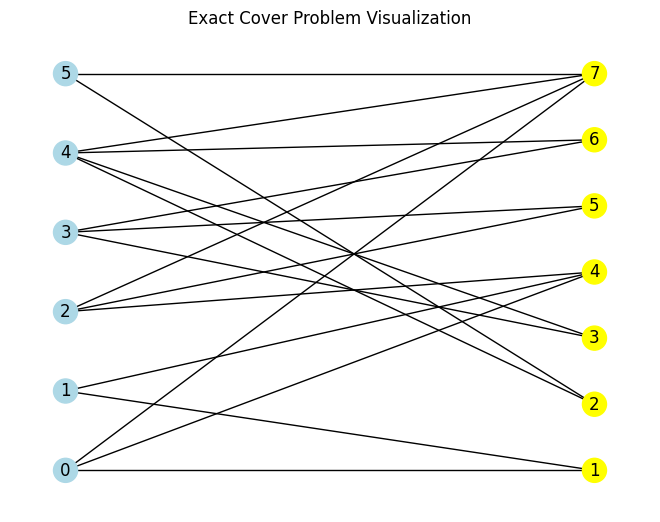

In [8]:
from quantum_launcher.problems import EC
pr = EC.from_preset("toy",onehot="exact")
pr.visualize()

## Quantum Approximate Optimization Algorithm

Algorithm we're going to use is Quantum Approximate Optimization Algorithm (QAOA), let's initialize it!

In [9]:
from quantum_launcher.routines.qiskit_routines import QAOA
alg = QAOA()

Now we need to define the backend our algorithm will run on, you can use a local simulator or a real AQT computer if you have access to one 

In [10]:
from quantum_launcher.routines.qiskit_routines import QiskitBackend, AQTBackend
#backend = AQTBackend() 
backend = QiskitBackend('local_simulator')

Now we can use Quantum launcher to launch QAOA on selected backend 

In [11]:
from quantum_launcher.launcher import QuantumLauncher
launcher = QuantumLauncher(pr, alg, backend)
result = launcher.run()
result

Result(bitstring=101010, energy=3.5625)

Be careful! QAOA returns reversed bitstring!

The results corresponds to the following matching:

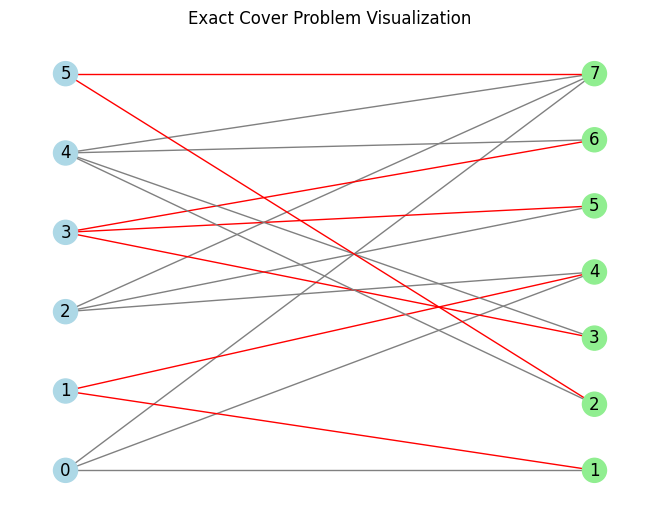

In [12]:
pr.visualize(result.best_bitstring[::-1])

as you can see QAOA solved this problem with flying colors

Quantum launcher allows you to easily test different combinations of problems, algorithms and backend simply by swapping out the arguments, let's try out the Traveling Salesperson Problem:

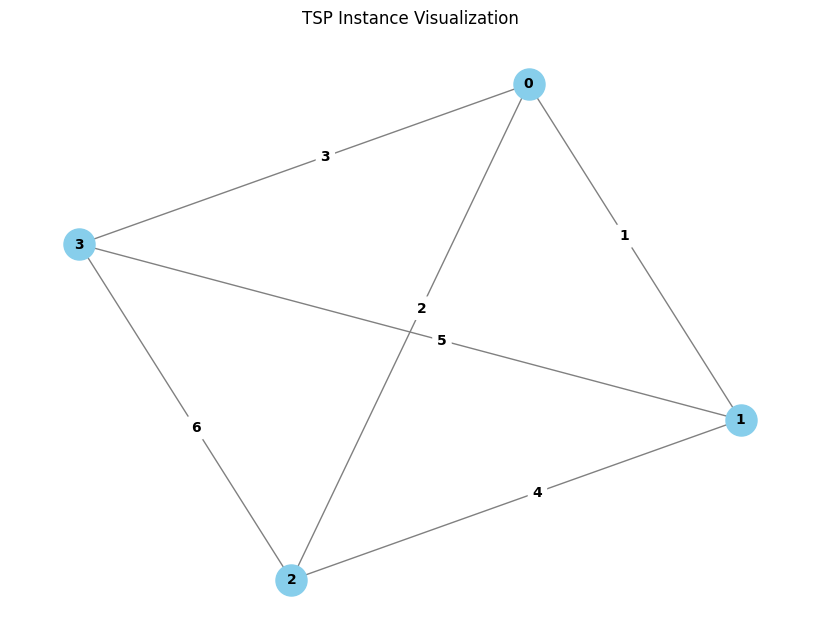

In [13]:
from quantum_launcher.problems import TSP
pr = TSP.from_preset(instance_name="default")
pr.visualize()

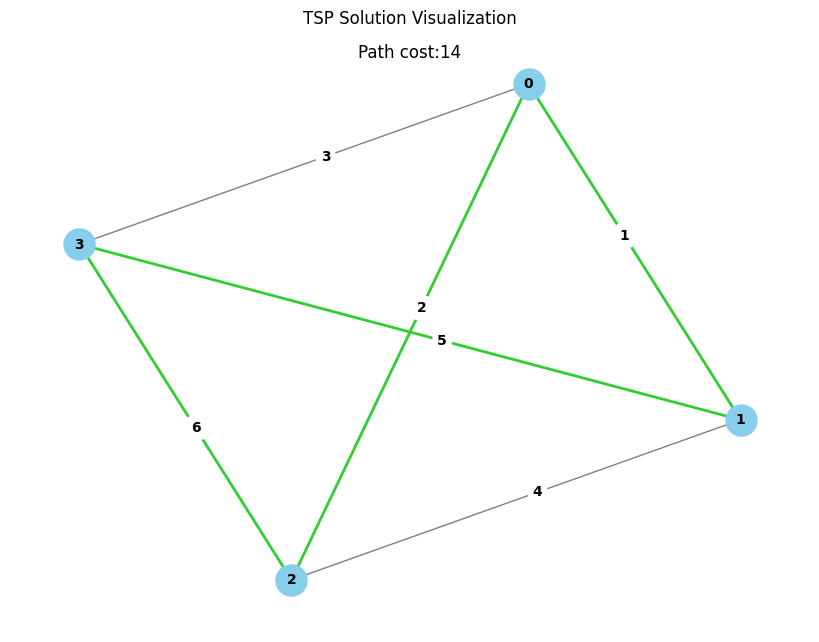

In [14]:
launcher = QuantumLauncher(pr,alg,backend)
result = launcher.run()
pr.visualize(result.best_bitstring)